# Phase 3: High-Frequency ICU Telemetry (Dataset 3)

The Intensive Care Unit (ICU) requires a real-time triage model. 

Patients are continuously monitored across 50 high-frequency physiological metrics. 

You must classify the patient’s state into one of three categories: Stable (Class 0), At-Risk (Class 1), or Critical (Class 2). 

The core difficulty lies in the “Stable” class, which consists of two vastly different physiological states:
1. patients who are awake and resting, 

2. patients who are in a state of chemically induced deep sleep.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import seaborn
import scipy
from scipy.stats import multivariate_normal
import cvxopt

In [2]:
dataset = np.genfromtxt("../PRNN_2026_A1_data/dataset_3.csv", delimiter=",", dtype=float, skip_header=1, filling_values=np.nan)

print(dataset.shape)

print(np.isnan(dataset).any())

(20000, 51)
False


In [3]:
x = dataset[:, :-1]
y = dataset[:, -1:]

print(x.shape, y.shape)

(20000, 50) (20000, 1)


In [4]:
num_features = x.shape[1]
num_data = x.shape[0]
print(num_data, num_features)

20000 50


## 3.5 Vectorized Logistic Regression:
Filter Dataset 3 to include only Class 1 and Class 2.

Implement binary Logistic Regression with L2 regularization using gradient descent. Plot
the learning curve. 

Demonstrate empirically how the curve behaves when you increase
the learning rate to a point that violates the Lipschitz smoothness condition.

In [5]:
# Filter Dataset 3 to include only Class 1 and Class 2
mask = ((y == 1) | (y == 2)).flatten()
x_filtered = x[mask]
y_filtered = y[mask]

# Remap labels to 0 and 1 for binary classification (Class 1 -> 0, Class 2 -> 1)
y_filtered = y_filtered - 1

print(f"Original shape: {x.shape}, {y.shape}")
print(f"Filtered shape: {x_filtered.shape}, {y_filtered.shape}")

Original shape: (20000, 50), (20000, 1)
Filtered shape: (10000, 50), (10000, 1)


In [6]:
def sigmoid(z):
    z = np.clip(z, -500, 500) # clip to avoid overflow
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, lamda):
    m = X.shape[0]
    epsilon = 1e-15 # to avoid log(0)

    h = sigmoid(X @ w)

    bce_cost = - (1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    reg_cost = lamda * (0.5 / m) * np.sum(w[1:]**2) 

    return bce_cost + reg_cost

def gradient_descent(X, y, w_init, lamda, lr = 0.001, epochs = 10):
    m = X.shape[0]
    w = w_init.copy()
    loss_history = []
    
    for i in range(epochs):
        cost = compute_cost(X, y, w, lamda)
        loss_history.append(cost)
        print(f"Epoch {i} Loss: {cost}")
        
        h = sigmoid(X @ w)
        bce_grad = (1/m) * X.T @ (h - y)
        
        # Regularization gradient
        reg_grad = (lamda / m) * w
        reg_grad[0] = 0 # skipping the bias term
        grad = bce_grad + reg_grad
        
        w = w - lr * grad
        
    return w, loss_history

In [7]:
X_augmented = np.hstack((np.ones((x_filtered.shape[0], 1)), x_filtered))
w_init = np.zeros((X_augmented.shape[1], 1))

Epoch 0 Loss: 0.6931471805599435
Epoch 1 Loss: 0.6662633583356316
Epoch 2 Loss: 0.6409328827666003
Epoch 3 Loss: 0.6170622250406078
Epoch 4 Loss: 0.5945613081671112
Epoch 5 Loss: 0.5733439226808973
Epoch 6 Loss: 0.5533280062647362
Epoch 7 Loss: 0.5344358072437777
Epoch 8 Loss: 0.516593951479373
Epoch 9 Loss: 0.49973343095240275
Epoch 10 Loss: 0.4837895305867914
Epoch 11 Loss: 0.46870170786999793
Epoch 12 Loss: 0.45441343776365356
Epoch 13 Loss: 0.4408720333933178
Epoch 14 Loss: 0.4280284511444998
Epoch 15 Loss: 0.4158370871196521
Epoch 16 Loss: 0.40425557044812943
Epoch 17 Loss: 0.39324455768998345
Epoch 18 Loss: 0.382767531524698
Epoch 19 Loss: 0.3727906060502197
Epoch 20 Loss: 0.36328234031506895
Epoch 21 Loss: 0.35421356114500585
Epoch 22 Loss: 0.34555719588437334
Epoch 23 Loss: 0.3372881153310515
Epoch 24 Loss: 0.32938298688522255
Epoch 25 Loss: 0.3218201377403699
Epoch 26 Loss: 0.3145794278068791
Epoch 27 Loss: 0.30764213196311174
Epoch 28 Loss: 0.30099083116664044
Epoch 29 Loss: 

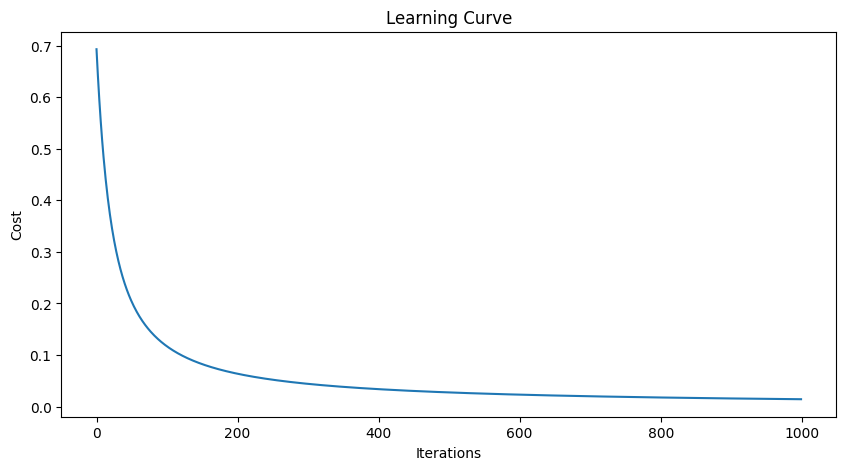

In [8]:
lamda = 0.1
total_epochs = 1000
lr = 0.0001

w, loss_history = gradient_descent(X_augmented, y_filtered, w_init, lamda, lr, total_epochs)

plt.figure(figsize=(10, 5))
plt.plot(range(total_epochs), loss_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Learning Curve')
plt.show()

Epoch 0 Loss: 0.6931471805599435
Epoch 1 Loss: 2.1827258589080922
Epoch 2 Loss: 2.180980027457103
Epoch 3 Loss: 2.179235592391942
Epoch 4 Loss: 2.177492552595723
Epoch 5 Loss: 2.175750906952455
Epoch 6 Loss: 2.1740106543470383
Epoch 7 Loss: 2.172271793665266
Epoch 8 Loss: 2.17053432379382
Epoch 9 Loss: 2.1687982436202766
Epoch 10 Loss: 2.1670635520331
Epoch 11 Loss: 2.1653302479216414
Epoch 12 Loss: 2.1635983301761437
Epoch 13 Loss: 2.1618677976877354
Epoch 14 Loss: 2.160138649348433
Epoch 15 Loss: 2.1584108840511385
Epoch 16 Loss: 2.156684500689639
Epoch 17 Loss: 2.1549594981586075
Epoch 18 Loss: 2.1532358753536003
Epoch 19 Loss: 2.1515136311710568
Epoch 20 Loss: 2.1497927645083017
Epoch 21 Loss: 2.1480732742635373
Epoch 22 Loss: 2.14635515933585
Epoch 23 Loss: 2.144638418625207
Epoch 24 Loss: 2.142923051032454
Epoch 25 Loss: 2.1412090554593157
Epoch 26 Loss: 2.1394964308083972
Epoch 27 Loss: 2.1377851759831796
Epoch 28 Loss: 2.136075289888021
Epoch 29 Loss: 2.134366771428157
Epoch 30

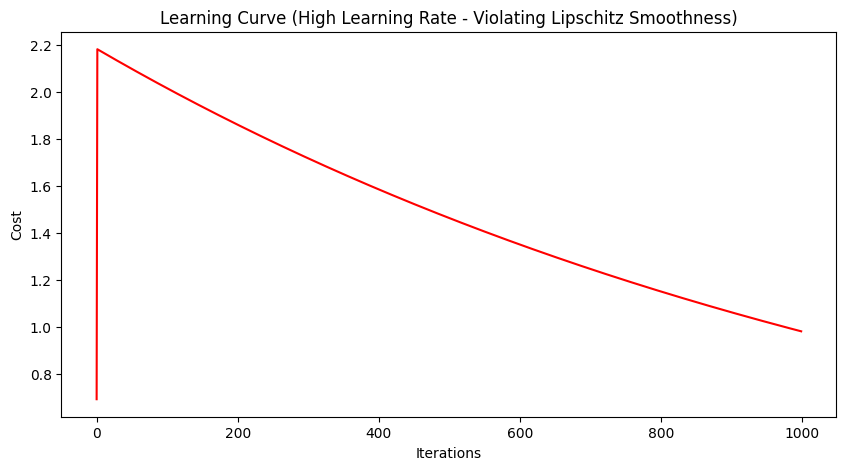

In [9]:
high_learning_rate = 40.0

w_highw, loss_history_high = gradient_descent(X_augmented, y_filtered, w_init, lamda, high_learning_rate, total_epochs)

plt.figure(figsize=(10, 5))
plt.plot(range(total_epochs), loss_history_high, color='red')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Learning Curve (High Learning Rate - Violating Lipschitz Smoothness)')
plt.show()


## 3.6 GMM Initialization & The E-Step:
Implement the EM algorithm for a Gaussian Mixture Model. 

Initialize a GMM with K = 4 on Dataset 3 using random means and spherical covariances. 

Execute exactly one E-step and one M-step. 

Report the initial marginal log-likelihood of the dataset, and the exact log-likelihood after this single iteration.

In [10]:
np.random.seed(42)
K = 4
N, D = x.shape

# Initialize pi, mu, Sigma
pi = np.ones(K) / K

# Random means
random_indices = np.random.choice(N, K, replace=False)
mu = x[random_indices, :]

# Spherical covariances: Sigma_k = sigma^2 * I
# we can initialize sigma to the mean variance across all dimensions
sigma_squared = np.var(x, axis=0).mean()
Sigma = np.array([sigma_squared * np.eye(D) for _ in range(K)])

def e_step(X, pi, mu, Sigma, K):
    N = X.shape[0]
    log_densities = np.zeros((N, K))
    for k in range(K):
        # # add small epsilon to diagonal for strict positive definiteness
        # cov_k = Sigma[k] + 1e-6 * np.eye(Sigma[k].shape[0])
        # log_densities[:, k] = np.log(pi[k] + 1e-15) + multivariate_normal.logpdf(X, mean=mu[k], cov=cov_k)
        cov_k = Sigma[k]
        log_densities[:, k] = np.log(pi[k]) + multivariate_normal.logpdf(X, mean=mu[k], cov=cov_k)
        
    # log-sum-exp trick to avoid numerical underflow in 50D
    max_log_densities = np.max(log_densities, axis=1, keepdims=True)
    exp_log_densities = np.exp(log_densities - max_log_densities)
    sum_exp_log_densities = np.sum(exp_log_densities, axis=1, keepdims=True)
    
    # log_marginal_densities = np.squeeze(max_log_densities) + np.squeeze(np.log(sum_exp_log_densities + 1e-15))
    log_marginal_densities = np.squeeze(max_log_densities) + np.squeeze(np.log(sum_exp_log_densities))

    log_likelihood = np.sum(log_marginal_densities)
    
    # Compute responsibilities
    gamma = exp_log_densities / (sum_exp_log_densities + 1e-15)
    
    return log_likelihood, gamma

def m_step(X, gamma, K):
    N = X.shape[0]
    D = X.shape[1]
    
    N_k = np.sum(gamma, axis=0)
    pi_new = N_k / N
    
    mu_new = np.zeros((K, D))
    Sigma_new = np.zeros((K, D, D))
    
    for k in range(K):
        # Update mean
        mu_new[k] = np.sum(gamma[:, k:k+1] * X, axis=0) / (N_k[k] + 1e-15)
        
        # Update covariance
        diff = X - mu_new[k]
        Sigma_new[k] = np.dot(gamma[:, k] * diff.T, diff) / (N_k[k] + 1e-15)
        # # Add regularizer to ensure pos-definiteness for next steps
        # Sigma_new[k] += 1e-6 * np.eye(D)
        
    return pi_new, mu_new, Sigma_new

In [11]:
# 1. Initial State / E-step
initial_ll, gamma = e_step(x, pi, mu, Sigma, K)
print(f"Initial marginal log-likelihood: {initial_ll:.2f}")

# 2. M-step
pi, mu, Sigma = m_step(x, gamma, K)

# 3. E-step again to compute log-likelihood after one full iteration
new_ll, _ = e_step(x, pi, mu, Sigma, K)
print(f"Marginal log-likelihood after one iteration: {new_ll:.2f}")

Initial marginal log-likelihood: -2691464.23
Marginal log-likelihood after one iteration: -1718835.45


## 3.7 EM Convergence & Crashes:
Run your GMM on Dataset 3 for K = 2, 4, 6. 

Plot the
log-likelihood over iterations to empirically verify monotonic convergence. 

Programmatically force one of the covariance matrices to zero variance mid-training, and document
the exact Python error that breaks the Multivariate Normal PDF computation

In [12]:
def run_gmm(X, K, total_epochs=50, tol=1e-4, force_crash=False):
    N, D = X.shape
    np.random.seed(42)
    pi = np.ones(K) / K
    random_indices = np.random.choice(N, K, replace=False)
    mu = X[random_indices, :]
    sigma_squared = np.var(X, axis=0).mean()
    Sigma = np.array([sigma_squared * np.eye(D) for _ in range(K)])
    
    log_likelihoods = []
    for i in range(total_epochs):
        if force_crash and i == 2: # Force crash mid-training
            # Force one covariance matrix to zero variance
            Sigma[0] = np.zeros((D, D))
            
        try:
            ll, gamma = e_step(X, pi, mu, Sigma, K)
            log_likelihoods.append(ll)
            pi, mu, Sigma = m_step(X, gamma, K)
            
            if i > 0 and ll - log_likelihoods[-2] < tol:
                break
        except Exception as e:
            if force_crash:
                import traceback
                error_details = traceback.format_exc()
                return log_likelihoods, (type(e).__name__, str(e), error_details)
            raise e
            
    return log_likelihoods, pi, mu, Sigma

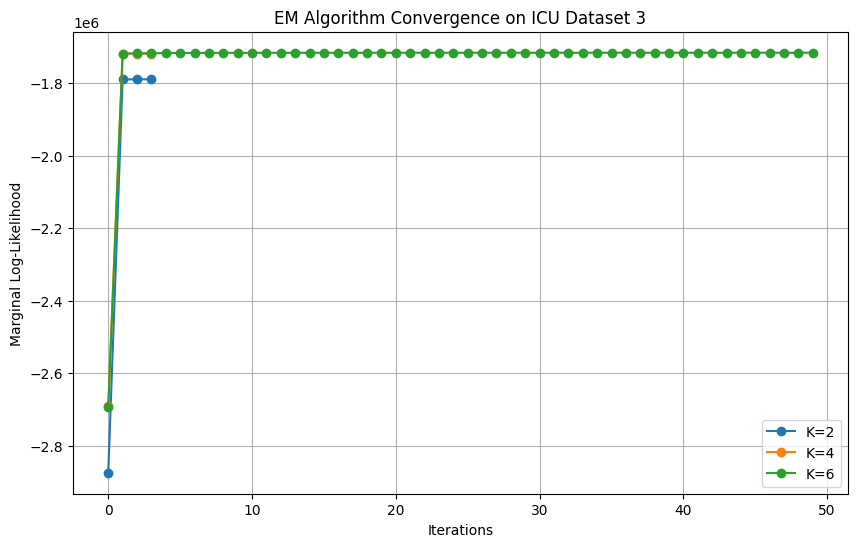

In [13]:
plt.figure(figsize=(10, 6))
for k in [2, 4, 6]:
    # print(k)
    lls, pi, mu, Sigma = run_gmm(x, K=k)
    plt.plot(range(len(lls)), lls, marker='o', label=f'K={k}')

plt.xlabel('Iterations')
plt.ylabel('Marginal Log-Likelihood')
plt.title('EM Algorithm Convergence on ICU Dataset 3')
plt.legend()
plt.grid(True)
plt.show()

In [51]:
# 2. To force one covariance matrix to zero variance
_, crash_error = run_gmm(x, K=2, force_crash=True)
if crash_error:
    err_type, err_msg, _ = crash_error
    print(f"\n--- CRASH DOCUMENTATION ---")
    print(f"Error Type : {err_type}")
    print(f"Error Msg  : {err_msg}")
    print(f"Reason     : Multivariate Normal PDF computation expects a positive definitive covariance matrix.\n"
          f"             When we force a covariance matrix to have zero variance, it becomes singular\n"
          f"             (determinant is 0), meaning its inverse cannot be computed, violating the mathematical\n"
          f"             requirements of the Gaussian distribution.")


--- CRASH DOCUMENTATION ---
Error Type : LinAlgError
Error Msg  : When `allow_singular is False`, the input matrix must be symmetric positive definite.
Reason     : Multivariate Normal PDF computation expects a positive definitive covariance matrix.
             When we force a covariance matrix to have zero variance, it becomes singular
             (determinant is 0), meaning its inverse cannot be computed, violating the mathematical
             requirements of the Gaussian distribution.


## 3.8 Decision Boundaries: 
Extract the first two dimensions of Dataset 3. 

Train a GMM
(K = 3) on this subset. 

Plot a dense grid of the resulting Bayes Optimal decision boundaries, and overlay the contour lines of the learned Gaussian covariance matrices on top of
the data scatter plot

In [79]:
x_filtered = x[:,:2]
# y_filtered = y
print(x_filtered.shape)

(20000, 2)


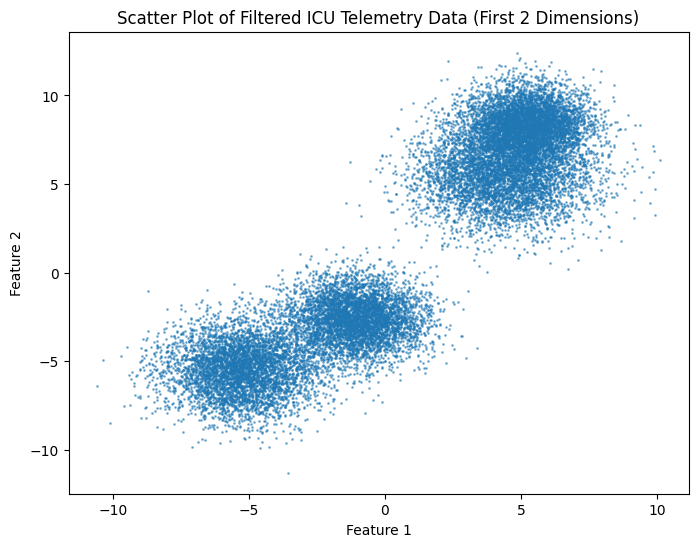

In [82]:
plt.figure(figsize=(8, 6))
plt.scatter(x_filtered[:, 0], x_filtered[:, 1], alpha=0.5, s=1)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot of Filtered ICU Telemetry Data (First 2 Dimensions)')
plt.show()

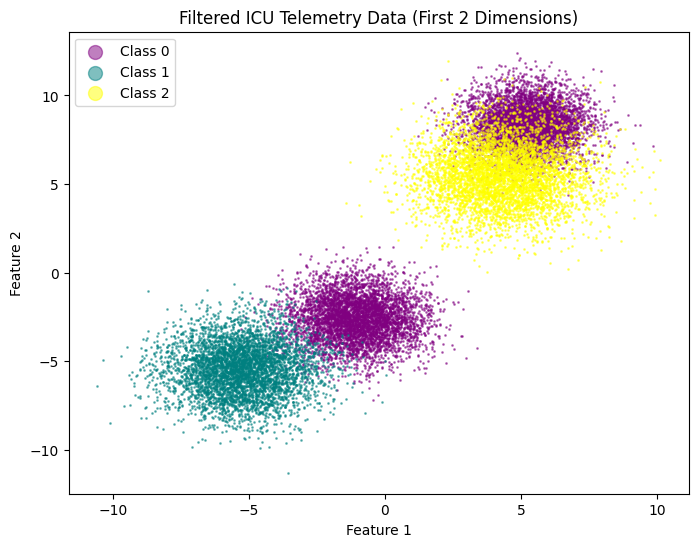

In [81]:
plt.figure(figsize=(8, 6))

colors = ['purple', 'teal', 'yellow']
y_flattened = y.flatten().astype('int')
classes = np.unique(y_flattened)

for class_id, color in zip(classes, colors):
    mask = (y_flattened == class_id)
    plt.scatter(x_filtered[mask, 0], x_filtered[mask, 1], c=color, label=f'Class {class_id}', alpha=0.5, s=1)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Filtered ICU Telemetry Data (First 2 Dimensions)')

plt.legend(markerscale=10) 
plt.show()

In [87]:
K = 3
lls, pi, mu, Sigma = run_gmm(x_filtered, K=K)
print(f"Initial Marginal log-likelihood: {lls[0]:.2f}")
print(f"Final Marginal log-likelihood: {lls[-1]:.2f}")

Initial Marginal log-likelihood: -120133.21
Final Marginal log-likelihood: -94021.63


In [88]:
pi, mu, Sigma

(array([0.49843562, 0.35448954, 0.14707483]),
 array([[ 4.79794322,  6.97434687],
        [-3.40178138, -3.97461865],
        [-2.49027595, -4.12651886]]),
 array([[[2.06735248, 0.60958952],
         [0.60958952, 3.82340478]],
 
        [[6.56747615, 2.9461952 ],
         [2.9461952 , 3.3854105 ]],
 
        [[4.90392722, 3.54432355],
         [3.54432355, 5.0069165 ]]]))

In [ ]:
# ------------------------------------------------------------------
# 1. Create a dense grid over the data range
# ------------------------------------------------------------------
margin = 0.5
# feature 1
x_min, x_max = x_filtered[:, 0].min() - margin, x_filtered[:, 0].max() + margin 
# feature 2
y_min, y_max = x_filtered[:, 1].min() - margin, x_filtered[:, 1].max() + margin 

resolution = 300  # increase for finer grid 
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, resolution),
    np.linspace(y_min, y_max, resolution),
)
grid_points = np.c_[xx.ravel(), yy.ravel()]  # shape (resolution^2, 2)

In [93]:
grid_points

array([[-11.09003499, -11.79952711],
       [-11.01740861, -11.79952711],
       [-10.94478223, -11.79952711],
       ...,
       [ 10.48000039,  12.91173025],
       [ 10.55262677,  12.91173025],
       [ 10.62525315,  12.91173025]], shape=(90000, 2))

In [94]:
# ------------------------------------------------------------------
# 2. Compute posterior probability P(k | x) for each grid point
# ------------------------------------------------------------------
# log-likelihood of each grid point under each Gaussian component
log_densities = np.zeros((grid_points.shape[0], K))
for k in range(K):
    log_densities[:, k] = np.log(pi[k] + 1e-15) + multivariate_normal.logpdf( grid_points, mean=mu[k], cov=Sigma[k])

# Bayes Optimal decision: pick the component with highest posterior
predicted_class = np.argmax(log_densities, axis=1)
decision_grid = predicted_class.reshape(xx.shape)

In [97]:
predicted_class

array([2, 2, 2, ..., 0, 0, 0], shape=(90000,))

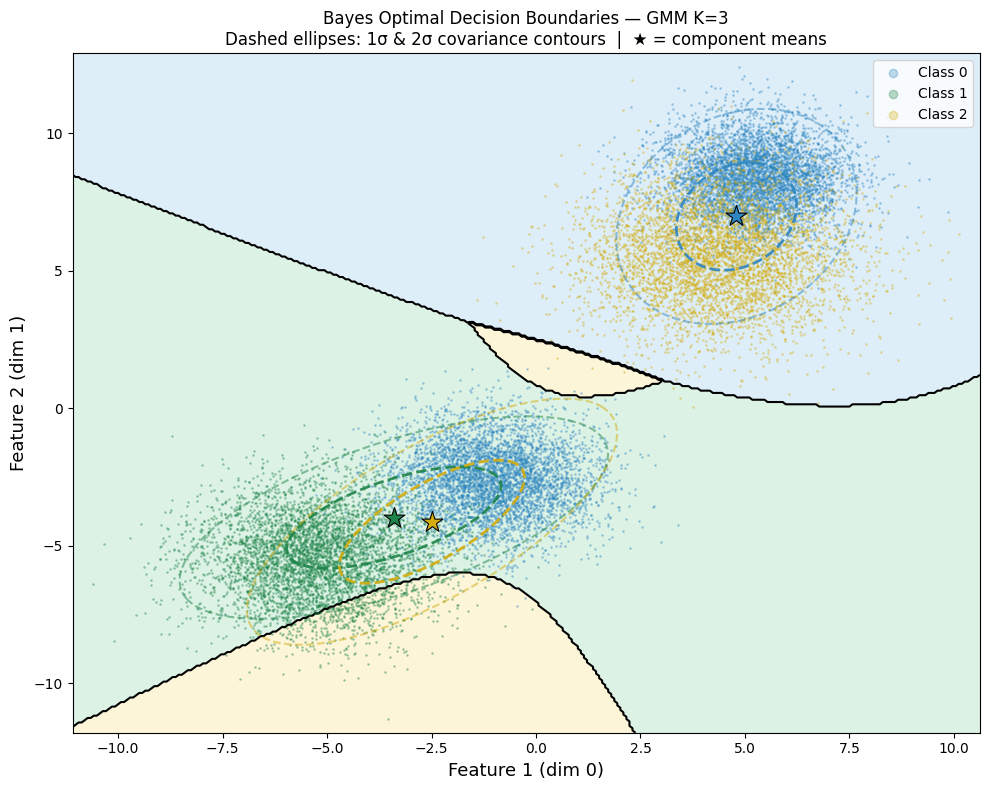

In [98]:
# ------------------------------------------------------------------
# 3. Helper to draw a covariance ellipse
# ------------------------------------------------------------------
def draw_covariance_ellipse(ax, mean, cov, n_std=2.0, **kwargs):
    """Draw an ellipse representing the n_std-sigma covariance region."""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # Angle of the principal axis
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    # Width and height are 2*n_std * sqrt(eigenvalue)
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse(
        xy=mean, width=width, height=height, angle=angle, **kwargs
    )
    ax.add_patch(ellipse)

# ------------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------------
colors_bg = ['#AED6F1', '#A9DFBF', '#F9E79F']   # soft background colours
colors_fg = ['#2E86C1', '#1E8449', '#D4AC0D']   # darker for scatter / ellipses
class_colors = np.array(colors_fg)

fig, ax = plt.subplots(figsize=(10, 8))

# --- Decision region background ---
# pcolormesh is faster than contourf for discrete classes
cmap_bg = plt.cm.colors.ListedColormap(colors_bg[:K])
ax.pcolormesh(xx, yy, decision_grid, cmap=cmap_bg, alpha=0.4, shading='auto')

# --- Data scatter (colour by true class label) ---
y_flat = y.flatten().astype(int)
for cls in np.unique(y_flat):
    mask = (y_flat == cls)
    ax.scatter(
        x_filtered[mask, 0], x_filtered[mask, 1],
        c=class_colors[cls % K],
        s=1, alpha=0.3,
        label=f'Class {cls}'
    )

# --- Decision boundary contour lines ---
ax.contour(
    xx, yy, decision_grid,
    levels=np.arange(K + 1) - 0.5,
    colors='k', linewidths=1.5
)

# --- Covariance ellipses (1σ and 2σ) at each component mean ---
for k in range(K):
    for n_std, alpha, lw in [(1, 0.9, 2.0), (2, 0.5, 1.5)]:
        draw_covariance_ellipse(
            ax, mu[k], Sigma[k],
            n_std=n_std,
            edgecolor=colors_fg[k],
            facecolor='none',
            linewidth=lw,
            linestyle='--',
            alpha=alpha,
            zorder=5
        )
    # Mark the component mean
    ax.scatter(*mu[k], marker='*', s=250, color=colors_fg[k],
               edgecolor='k', linewidth=0.8, zorder=6)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Feature 1 (dim 0)', fontsize=13)
ax.set_ylabel('Feature 2 (dim 1)', fontsize=13)
ax.set_title(
    f'Bayes Optimal Decision Boundaries — GMM K={K}\n'
    'Dashed ellipses: 1σ & 2σ covariance contours  |  ★ = component means',
    fontsize=12
)
ax.legend(loc='upper right', markerscale=6, fontsize=10)
plt.tight_layout()
plt.show()

## 3.9 SVM with Slack KKT Verification:
Filter Dataset 3 for Class 1 and Class 2. Implement the soft-margin SVM dual and train it with C = 1.0. 

Programmatically evaluate your optimized μ array to verify the KKT conditions. 

Print the index and μ value of: 
(a) one point strictly inside the margin, 
(b) one point exactly on the margin boundary, and 
(c) one point safely classified outside the margin.

In [27]:
# Filter Dataset 3 to include only Class 1 and Class 2
mask = ((y == 1) | (y == 2)).flatten()
x_filtered = x[mask]
y_filtered = y[mask]
y_filtered = np.where(y_filtered == 2,-1, 1) # (Class 2 -> -1, Class 1 -> 1)

print(f"Original shape: {x.shape}, {y.shape}")
print(f"Filtered shape: {x_filtered.shape}, {y_filtered.shape}")

Original shape: (20000, 50), (20000, 1)
Filtered shape: (10000, 50), (10000, 1)


In [28]:
x_filtered = x_filtered[:1000, :]
y_filtered = y_filtered[:1000, :]
print(f"Filtered shape: {x_filtered.shape}, {y_filtered.shape}")

Filtered shape: (1000, 50), (1000, 1)


In [23]:
y_filtered = np.where(y_filtered == 2,-1, 1) # (Class 2 -> -1, Class 1 -> 1)

In [24]:
def run_svm_dual(X, Y, C = np.inf):
    def objective_fn(mu):
        return 0.5 * (mu.T @ kernal_matrix @ mu) - np.sum(mu)
    
    def gradient_fn(mu):
        return (kernal_matrix @ mu) - 1.0

    Y_flat = Y.flatten()

    kernal_matrix = np.outer(Y_flat, Y_flat) * (X @ X.T) + 1e-9 * np.eye(X.shape[0])
    # mu0 = np.zeros_like(Y_flat)
    mu0 = np.ones_like(Y_flat) * 0.1

    # ineq constraint: inf > mu_i >= 0
    ineq_constr = scipy.optimize.Bounds(np.zeros_like(Y_flat), C * np.ones_like(Y_flat))

    # eq constraint: sum(y_i, mu_i) = 0
    eq_constr = scipy.optimize.LinearConstraint(Y_flat.reshape(1,-1), 0, 0)

    results = scipy.optimize.minimize(
        fun=objective_fn, x0=mu0, method='SLSQP', 
        bounds=ineq_constr, 
        constraints=[eq_constr], 
        jac = gradient_fn)

    return results

In [25]:
C = 1

results = run_svm_dual(x_filtered, y_filtered, C)
print(f"Optimization results: {results}")

/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1659773574.py:10: RuntimeWarning: divide by zero encountered in matmul
  kernal_matrix = np.outer(Y_flat, Y_flat) * (X @ X.T) + 1e-9 * np.eye(X.shape[0])
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1659773574.py:10: RuntimeWarning: overflow encountered in matmul
  kernal_matrix = np.outer(Y_flat, Y_flat) * (X @ X.T) + 1e-9 * np.eye(X.shape[0])
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1659773574.py:10: RuntimeWarning: invalid value encountered in matmul
  kernal_matrix = np.outer(Y_flat, Y_flat) * (X @ X.T) + 1e-9 * np.eye(X.shape[0])
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1659773574.py:3: RuntimeWarning: divide by zero encountered in matmul
  return 0.5 * (mu.T @ kernal_matrix @ mu) - np.sum(mu)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1659773574.py:3: RuntimeWarning: overflow encountered in matmul
  return 0.5 * (mu.T @ kernal_

Optimization results:  message: Optimization terminated successfully
 success: True
  status: 0
     fun: -4.7593924545617654e-15
       x: [ 0.000e+00  0.000e+00 ...  2.374e-17  6.050e-18]
     nit: 5
     jac: [-1.000e+00 -1.000e+00 ... -1.000e+00 -1.000e+00]
    nfev: 15
    njev: 5


In [15]:
optimal_mu = results.x
print(np.min(optimal_mu), np.max(optimal_mu))

0.0 5.96959175071677e-17


In [ ]:
def run_svm_dual_scaled(X, Y, C = np.inf):
    def objective_fn(mu):
        return 0.5 * (mu.T @ kernal_matrix @ mu) - np.sum(mu)
    
    def gradient_fn(mu):
        return (kernal_matrix @ mu) - np.ones_like(mu)

    Y_flat = Y.flatten()

    num_features = X.shape[1]

    kernal_matrix = np.outer(Y_flat, Y_flat) * (X @ X.T) / num_features
    # mu0 = np.zeros_like(Y_flat)
    mu0 = np.ones_like(Y_flat) * 0.1

    # ineq constraint: inf > mu_i >= 0
    ineq_constr = scipy.optimize.Bounds(np.zeros_like(Y_flat), C * np.ones_like(Y_flat))

    # eq constraint: sum(y_i, mu_i) = 0
    eq_constr = scipy.optimize.LinearConstraint(Y_flat.reshape(1,-1), 0, 0)

    results = scipy.optimize.minimize(
        fun=objective_fn, x0=mu0, method='SLSQP', 
        bounds=ineq_constr, 
        constraints=[eq_constr], 
        jac = gradient_fn)

    return results

In [ ]:
C = 1

results = run_svm_dual_scaled(x_filtered, y_filtered, C)
print(f"Optimization results: {results}")

Optimization results:  message: Optimization terminated successfully
 success: True
  status: 0
     fun: -0.7175764063246486
       x: [ 8.531e-16  0.000e+00 ...  0.000e+00  3.223e-16]
     nit: 16
     jac: [ 1.784e-01  5.067e-02 ...  6.051e-02  2.684e-01]
    nfev: 16
    njev: 16


In [ ]:
# cvxopt.solvers.qp solves this standard form:

# minimize:  0.5 * xᵀPx + qᵀx
# subject to: 
    # Gx <= h     
    # Ax = b

# our svm dual problem:

# minimize:  0.5 * μᵀKμ - Σμᵢ
# subject to: 
    # 0 <= μᵢ <= C
    # Σ(yᵢμᵢ) = 0

In [ ]:
def run_svm_dual_cvxopt(X, Y, C = np.inf):
    Y_flat = Y.flatten().astype(float)
    n = X.shape[0]

    kernal_matrix = np.outer(Y_flat, Y_flat) * (X @ X.T)

    # matrices for the objective:
    P = cvxopt.matrix(kernal_matrix)
    q = cvxopt.matrix(-np.ones(n))

    # Equality constraint: y^T @ mu = 0
    A = cvxopt.matrix(Y_flat.reshape(1, -1))
    b = cvxopt.matrix(0.0)

    # Inequality constraint: 0 <= mu <= C
    if C == np.inf:
        # only lower bound: -mu <= 0
        G = cvxopt.matrix(-np.eye(n))
        h = cvxopt.matrix(np.zeros(n))
    else:
        # -mu <= 0  AND  mu <= C
        G = cvxopt.matrix(np.vstack([-np.eye(n), np.eye(n)]))
        h = cvxopt.matrix(np.hstack([np.zeros(n), C * np.ones(n)]))

    results = cvxopt.solvers.qp(P, q, G, h, A, b)
    
    # mu = np.array(results['x']).flatten()
    return results

def calculate_optimal_w_b(X, Y, mu, C, tolerance = 1e-5):
    Y = Y.flatten()

    w = (mu * Y) @ X 

    # Compute b using support vectors
    support_vectors_mask = (mu > tolerance) & (mu < C - tolerance)
    b = np.mean(Y[support_vectors_mask] - X[support_vectors_mask] @ w)
    return w, b

In [ ]:
# Filter Dataset 3 to include only Class 1 and Class 2
mask = ((y == 1) | (y == 2)).flatten()
x_filtered = x[mask]
y_filtered = y[mask]
y_filtered = np.where(y_filtered == 2,-1, 1) # (Class 2 -> -1, Class 1 -> 1)

In [43]:
C = 1
results = run_svm_dual_cvxopt(x_filtered, y_filtered, C)
optimal_mu = np.array(results['x']).flatten()

/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1008722891.py:5: RuntimeWarning: divide by zero encountered in matmul
  kernal_matrix = np.outer(Y_flat, Y_flat) * (X @ X.T)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1008722891.py:5: RuntimeWarning: overflow encountered in matmul
  kernal_matrix = np.outer(Y_flat, Y_flat) * (X @ X.T)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1008722891.py:5: RuntimeWarning: invalid value encountered in matmul
  kernal_matrix = np.outer(Y_flat, Y_flat) * (X @ X.T)


     pcost       dcost       gap    pres   dres
 0: -2.0460e+01 -1.1714e+04  5e+04  2e+00  5e-12
 1: -7.6680e+00 -3.8681e+03  5e+03  8e-02  4e-12
 2: -1.3231e-01 -1.0301e+02  1e+02  2e-03  4e-12
 3:  2.8456e-04 -1.1040e+00  1e+00  2e-05  6e-14
 4:  1.5314e-03 -1.5419e-02  2e-02  2e-07  3e-15
 5: -1.8575e-04 -1.5947e-03  1e-03  2e-09  5e-15
 6: -4.5262e-04 -7.0950e-04  3e-04  2e-10  2e-15
 7: -4.8638e-04 -7.2466e-04  2e-04  1e-10  2e-15
 8: -4.9455e-04 -7.3340e-04  2e-04  1e-10  2e-15
 9: -5.4952e-04 -7.0025e-04  2e-04  5e-11  1e-15
10: -5.5334e-04 -7.0446e-04  2e-04  5e-11  1e-15
11: -5.8488e-04 -6.9512e-04  1e-04  1e-11  1e-15
12: -5.8651e-04 -6.9852e-04  1e-04  1e-11  1e-15
13: -5.9653e-04 -6.7684e-04  8e-05  8e-12  1e-15
14: -5.9703e-04 -6.6934e-04  7e-05  1e-12  1e-15
15: -6.0888e-04 -6.5008e-04  4e-05  3e-13  1e-15
16: -6.1280e-04 -6.4283e-04  3e-05  1e-16  1e-15
17: -6.2598e-04 -6.2815e-04  2e-06  2e-16  1e-15
18: -6.2699e-04 -6.2701e-04  3e-08  2e-16  1e-15
Optimal solution foun

In [ ]:
# mu = optimal_mu
# Y_flat = y_filtered.flatten()

# # Recover primal weights w = sum_i(mu_i * y_i * x_i)
# w_opt = np.sum((mu * Y_flat)[:, None] * x_filtered, axis=0)

# # Points exactly on the margin boundary have 0 < mu < C
# tol = 1e-5
# on_margin_idx = np.where((mu > tol) & (mu < C - tol))[0]

# if len(on_margin_idx) > 0:
#     # Use the first valid support vector to compute b
#     # y_i(w^T x_i + b) = 1 => b = y_i - w^T x_i
#     idx = on_margin_idx[0]
#     b_opt = Y_flat[idx] - np.dot(w_opt, x_filtered[idx])
# else:
#     b_opt = 0.0
    
# # --- 3. Evaluate KKT Conditions ---
# # Margin for each point: y_i * (w^T x_i + b)
# margins = Y_flat * (x_filtered @ w_opt + b_opt)

# idx_inside = np.where(mu >= C - tol)[0]  # mu = C => strictly inside margin
# idx_margin = on_margin_idx                   # 0 < mu < C => exactly on margin
# idx_outside = np.where(mu <= tol)[0]         # mu = 0 => safely outside margin

# print("\n--- KKT Verification ---")
# if len(idx_inside) > 0:
#     i = idx_inside[0]
#     print(f"(a) Point strictly inside margin (mu = C):")
#     print(f"    Index: {i}, mu: {mu[i]:.4f}, Margin = {margins[i]:.4f} (expected < 1)")
# else:
#     print("(a) No points strictly inside margin found.")

# if len(idx_margin) > 0:
#     i = idx_margin[0]
#     print(f"\n(b) Point exactly on margin boundary (0 < mu < C):")
#     print(f"    Index: {i}, mu: {mu[i]:.4f}, Margin = {margins[i]:.4f} (expected ~ 1.0)")
# else:
#     print("\n(b) No points exactly on margin found.")

# if len(idx_outside) > 0:
#     i = idx_outside[0]
#     print(f"\n(c) Point safely classified outside margin (mu = 0):")
#     print(f"    Index: {i}, mu: {mu[i]:.4f}, Margin = {margins[i]:.4f} (expected > 1)")
# else:
#     print("\n(c) No points outside margin found.")


--- KKT Verification ---
(a) No points strictly inside margin found.

(b) Point exactly on margin boundary (0 < mu < C):
    Index: 2022, mu: 0.0003, Margin = 1.0000 (expected ~ 1.0)

(c) Point safely classified outside margin (mu = 0):
    Index: 0, mu: 0.0000, Margin = 1.1825 (expected > 1)


/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/3604046116.py:3: RuntimeWarning: divide by zero encountered in matmul
  margins = Y_flat * (x_filtered @ w_opt + b_opt)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/3604046116.py:3: RuntimeWarning: overflow encountered in matmul
  margins = Y_flat * (x_filtered @ w_opt + b_opt)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/3604046116.py:3: RuntimeWarning: invalid value encountered in matmul
  margins = Y_flat * (x_filtered @ w_opt + b_opt)


In [ ]:
tolerance = 1e-5
mu = optimal_mu
y_filtered = y_filtered.flatten()

w, b = calculate_optimal_w_b(x_filtered, y_filtered, mu, C, tolerance)

# Functional margin for each point: yᵢ(w·xᵢ + b)
functional_margin = y_filtered * (x_filtered @ w + b)

print(f"mu range: min={mu.min():.6f}, max={mu.max():.6f}")

mu range: min=0.000000, max=0.000346


/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1545659242.py:6: RuntimeWarning: divide by zero encountered in matmul
  w = (mu * y_filtered) @ x_filtered  # weight vector
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1545659242.py:6: RuntimeWarning: overflow encountered in matmul
  w = (mu * y_filtered) @ x_filtered  # weight vector
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1545659242.py:6: RuntimeWarning: invalid value encountered in matmul
  w = (mu * y_filtered) @ x_filtered  # weight vector
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1545659242.py:10: RuntimeWarning: divide by zero encountered in matmul
  b = np.mean(y_filtered[support_vectors_mask] - x_filtered[support_vectors_mask] @ w)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_98396/1545659242.py:10: RuntimeWarning: overflow encountered in matmul
  b = np.mean(y_filtered[support_vectors_mask] - x_filtered[support_vectors_mask] @ w)


In [84]:
# ── KKT Conditions ──────────────────────────────────────────
# 1. mu_i = 0        → point safely outside margin, functional_margin > 1
# 2. 0 < mu_i < C    → point exactly on margin boundary, functional_margin = 1  
# 3. mu_i = C        → point strictly inside margin, functional_margin < 1

In [85]:
outside_mask  = mu < tolerance                            # μ ≈ 0
print(f"Points outside  (mu ≈ 0):   {outside_mask.sum()}")
idx_outside  = np.where(outside_mask)[0][0]
print(f"\n  Safely outside margin (mu = 0):")
print(f"    index={idx_outside}, mu={mu[idx_outside]:.4f}, functional_margin={functional_margin[idx_outside]:.4f}  (should be > 1)")

Points outside  (mu ≈ 0):   9974

  Safely outside margin (mu = 0):
    index=0, mu=0.0000, functional_margin=1.1842  (should be > 1)


In [87]:
boundary_mask = (mu > tolerance) & (mu < C - tolerance)  # 0 < μ < C
print(f"Points boundary (0 < mu < C): {boundary_mask.sum()}")
idx_boundary = np.where(boundary_mask)[0][0]
print(f"\n  Exactly on margin boundary (0 < mu < C):")
print(f"    index={idx_boundary}, mu={mu[idx_boundary]:.4f}, functional_margin={functional_margin[idx_boundary]:.4f}  (should be ≈ 1)")


Points boundary (0 < mu < C): 26

  Exactly on margin boundary (0 < mu < C):
    index=224, mu=0.0000, functional_margin=1.0052  (should be ≈ 1)


In [88]:
inside_mask   = mu > C - tolerance                        # μ ≈ C
print(f"Points inside   (mu ≈ C):   {inside_mask.sum()}")
# idx_inside   = np.where(inside_mask)[0][0]
# print(f"\n  Strictly inside margin (mu = C):")
# print(f"    index={idx_inside}, mu={mu[idx_inside]:.4f}, functional_margin={functional_margin[idx_inside]:.4f}  (should be < 1)")

Points inside   (mu ≈ C):   0


## 3.10 Mercer’s Condition: 
Implement the RBF (Gaussian) Kernel function. 

Compute the full
N × N Kernel matrix K for a 1,000-sample subset of Dataset 3. 
Compute the eigenvalues
of K. 

Show programmatically that all eigenvalues are non-negative, verifying that your
kernel matrix is Positive Semi-Definite

In [6]:
def calculate_rbf_kernel_matrix(X, sigma):
    x_norm_sq = np.sum(X**2, axis=1).reshape(-1, 1) #(1000, 1)

    x_diff_norm_sq = x_norm_sq + x_norm_sq.T - 2 * X @ X.T # (1000, 1000)
    
    rbf_kernel_matrix = np.exp(-x_diff_norm_sq / (2 * sigma ** 2))

    return rbf_kernel_matrix


In [7]:
x_filtered = x[:1000, :]
print(x_filtered.shape)

(1000, 50)


In [9]:
sigma = 5
rbf_kernel_matrix = calculate_rbf_kernel_matrix(x_filtered, sigma)
print(rbf_kernel_matrix.shape)

(1000, 1000)


In [10]:
evals, evecs = np.linalg.eigh(rbf_kernel_matrix)

In [11]:
np.min(evals), np.max(evals)

(np.float64(0.3412900850879269), np.float64(28.245287229272392))

In [12]:
print(f"The minimum eigen value of the kernel matrix: {np.min(evals):.2f}. Hence, the matrix is positive semi-definite.")

The minimum eigen value of the kernel matrix: 0.34. Hence, the matrix is positive semi-definite.


## 3.11 Hyperparameter Topography: 
Write a script to perform a grid search over C ∈
{0.1, 1, 10, 100} and σ ∈ {0.001, 0.01, 0.1, 1, 10} for your RBF SVM. 

Generate a 2D heatmap
plot of the validation accuracy across this grid. 

Identify the precise hyperparameter coordinate (C, σ) where the model exhibits the most severe overfitting.

In [95]:
def calculate_rbf_kernel_matrix(X1, X2, sigma = 0.1):
    x1_norm_sq = np.sum(X1**2, axis=1).reshape(-1, 1) #(1000, 1)
    x2_norm_sq = np.sum(X2**2, axis=1).reshape(-1, 1) #(1000, 1)

    x_diff_norm_sq = x1_norm_sq + x2_norm_sq.T - 2 * X1 @ X2.T # (1000, 1000)
    
    rbf_kernel_matrix = np.exp(-x_diff_norm_sq / (2 * sigma ** 2))

    return rbf_kernel_matrix
    
def svm_dual_with_rbf_kernel(X, Y, C = np.inf, sigma = 0.1, tolerance = 1e-5):
    Y_flat = Y.flatten().astype(float)
    n = X.shape[0]

    rbf_kernel_matrix = calculate_rbf_kernel_matrix(X, X, sigma)
    full_kernal_matrix = np.outer(Y_flat, Y_flat) * rbf_kernel_matrix

    # matrices for the objective:
    P = cvxopt.matrix(full_kernal_matrix)
    q = cvxopt.matrix(-np.ones(n))

    # Equality constraint: y^T @ mu = 0
    A = cvxopt.matrix(Y_flat.reshape(1, -1))
    b = cvxopt.matrix(0.0)

    # Inequality constraint: 0 <= mu <= C
    if C == np.inf:
        # only lower bound: -mu <= 0
        G = cvxopt.matrix(-np.eye(n))
        h = cvxopt.matrix(np.zeros(n))
    else:
        # -mu <= 0  AND  mu <= C
        G = cvxopt.matrix(np.vstack([-np.eye(n), np.eye(n)]))
        h = cvxopt.matrix(np.hstack([np.zeros(n), C * np.ones(n)]))

    cvxopt.solvers.options['show_progress'] = False
    results = cvxopt.solvers.qp(P, q, G, h, A, b)
    
    mu = np.array(results['x']).flatten()
    b, support_vectors_mask = calculate_optimal_b_for_rbf(Y_flat, rbf_kernel_matrix, mu, C, tolerance)
    return mu, b, support_vectors_mask

def calculate_optimal_b_for_rbf(Y, K, mu, C, tolerance = 1e-5):
    Y = Y.flatten()

    # w = (mu * Y) @ phi(X) 
    
    if C == np.inf:
        support_vectors_mask = (mu > tolerance)
    else:
        support_vectors_mask = (mu > tolerance) & (mu < C - tolerance)

    # b = y_i - (mu * y).T @ K(:, i), where K(:, i) is the ith column of the rbf kernel matrix
    b = np.mean(Y[support_vectors_mask] - (mu * Y) @ K[:, support_vectors_mask])
    return b, support_vectors_mask

def calculate_predictions(X_train, Y_train, X_test, mu, support_vectors_mask, b, sigma = 0.1):
    Y_train_flat = Y_train.flatten()

    train_test_rbf_kernel = calculate_rbf_kernel_matrix(X_test, X_train, sigma=sigma) # (test, test)
    
    y_pred = train_test_rbf_kernel[:, support_vectors_mask] @ (mu[support_vectors_mask] * Y_train_flat[support_vectors_mask]) + b
    y_pred = np.where(y_pred >= 0, 1, -1)
    
    return y_pred

def hyperparameter_topography(Cs, sigmas, x_train, y_train, x_test, y_test, tolerance = 1e-5):
    train_accuracies = np.zeros((len(Cs), len(sigmas)))
    test_accuracies = np.zeros((len(Cs), len(sigmas)))

    for i, C in enumerate(Cs):
        for j, sigma in enumerate(sigmas):
            print(f"Performing RBF Kernel SVM for C: {C}, sigma:{sigma}")

            optimal_mu, optimal_b, support_vectors_mask = svm_dual_with_rbf_kernel(X=x_train, Y=y_train, C=C, sigma=sigma, tolerance = tolerance)

            print(f"    Number of SVs: {support_vectors_mask.sum()}")
            print(f"    b: {optimal_b}")
            print(f"    mu max: {optimal_mu.max()}, mu min: {optimal_mu.min()}")

            y_train_pred = calculate_predictions(X_train=x_train, Y_train=y_train, X_test=x_train, mu = optimal_mu, support_vectors_mask=support_vectors_mask, b=optimal_b, sigma=sigma)
            train_accuracy = np.mean(y_train_pred.reshape(-1, 1) == y_train.reshape(-1,1))

            y_test_pred = calculate_predictions(X_train=x_train, Y_train=y_train, X_test=x_test, mu = optimal_mu, support_vectors_mask=support_vectors_mask, b=optimal_b, sigma=sigma)
            test_accuracy = np.mean(y_test_pred.reshape(-1, 1) == y_test.reshape(-1,1))
            preds_data = np.unique(y_test_pred, return_counts=True)

            train_accuracies[i, j] = train_accuracy
            test_accuracies[i, j] = test_accuracy
            
            counts = dict(zip(*preds_data))
            print(f"    No. of points classified -1: {counts.get(-1, 0)}")
            print(f"    No. of points classified 1: {counts.get(1, 0)}")
            print(f"    Train accuracy: {train_accuracy}")
            print(f"    Test accuracy: {test_accuracy}")

    return train_accuracies, test_accuracies

In [96]:
def get_datasets_svm(x, y, train_test_split = 0.9, normalize = True):
    mask = ((y == 1) | (y == 2)).flatten()
    x_filtered = x[mask]
    y_filtered = y[mask]
    y_filtered = np.where(y_filtered == 2,-1, 1) # (Class 2 -> -1, Class 1 -> 1)

    total_dataset_size = x_filtered.shape[0]
    print(f"total dataset size: {total_dataset_size}")
    print(f"train test split: {train_test_split}")

    x_train = x_filtered[:train_dataset_size, :]
    y_train = y_filtered[:train_dataset_size, :]

    x_test = x_filtered[train_dataset_size:, :]
    y_test = y_filtered[train_dataset_size:, :]

    print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
    print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")

    # normalize
    if normalize:
        mean_x = np.mean(x_train, axis=0)
        std_x = np.std(x_train, axis=0)
        std_x[std_x == 0] = 1

        x_train = (x_train - mean_x) / std_x
        x_test = (x_test - mean_x) / std_x

    return x_train, y_train, x_test, y_test


In [ ]:
train_test_split = 0.9

x = dataset[:, :-1]
y = dataset[:, -1:]

total dataset size: 10000
train dataset size: 9000
x_train: (9000, 50), y_train: (9000, 1)
x_test: (1000, 50), y_test: (1000, 1)


In [ ]:
Cs = [0.1, 1, 10, 100]
sigmas = [0.001, 0.01, 0.1, 1, 10]
tolerance = 1e-5

x_train, y_train, x_test, y_test = get_datasets_svm(x, y, train_test_split = 0.9, normalize = True)

train_accuracies, test_accuracies = hyperparameter_topography(Cs, sigmas, x_train, y_train, x_test, y_test, tolerance = tolerance)

Performing RBF Kernel SVM for C: 0.1, sigma:0.001
    Number of SVs: 4520
    b: 0.9008849569188229
    mu max: 0.09999999880505271, mu min: 0.09911503959750739
    No. of points classified -1: 0
    No. of points classified 1: 1000
    Train accuracy: 0.5022222222222222
    Test accuracy: 0.48
Performing RBF Kernel SVM for C: 0.1, sigma:0.01
    Number of SVs: 4520
    b: 0.9008849569363878
    mu max: 0.09999999880507231, mu min: 0.09911504302877547
    No. of points classified -1: 0
    No. of points classified 1: 1000
    Train accuracy: 0.5022222222222222
    Test accuracy: 0.48
Performing RBF Kernel SVM for C: 0.1, sigma:0.1
    Number of SVs: 4520
    b: 0.9008849569365638
    mu max: 0.09999999880507231, mu min: 0.09911504306308787
    No. of points classified -1: 0
    No. of points classified 1: 1000
    Train accuracy: 0.5022222222222222
    Test accuracy: 0.48
Performing RBF Kernel SVM for C: 0.1, sigma:1
    Number of SVs: 1052
    b: -0.4752215673035448
    mu max: 0.0999

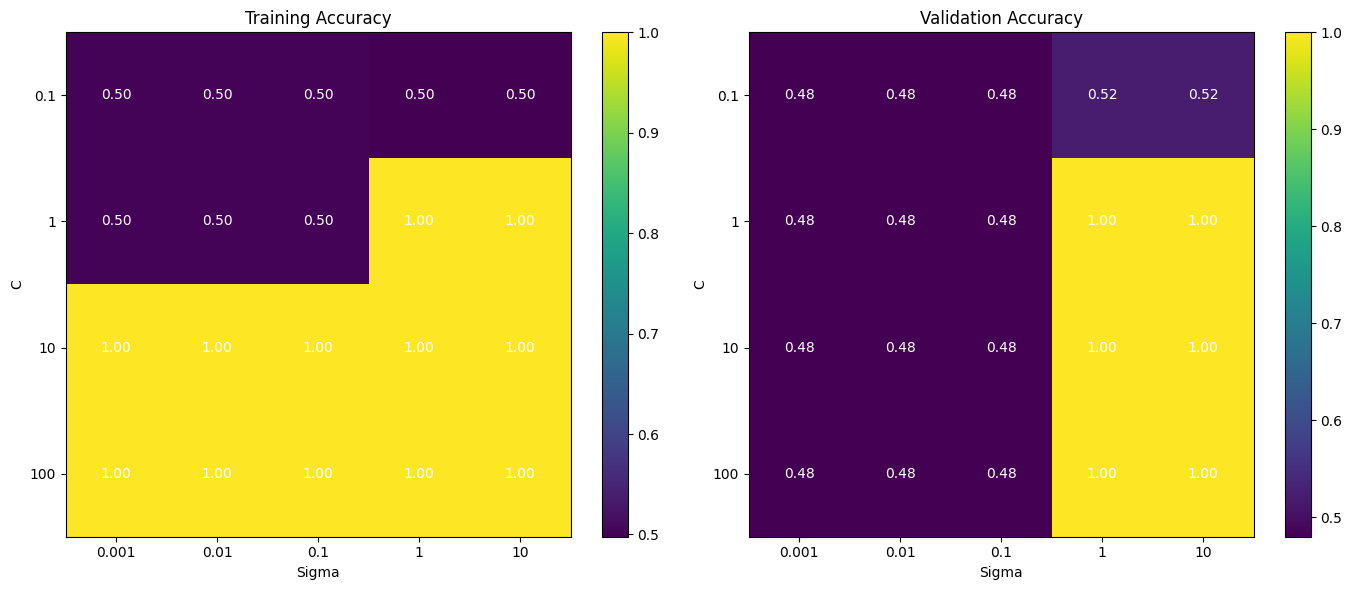

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

mats = [train_accuracies, test_accuracies]
titles = ["Training Accuracy", "Validation Accuracy"]

for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(mat, cmap='viridis', aspect='auto')

    ax.set_xticks(range(len(sigmas)))
    ax.set_yticks(range(len(Cs)))
    ax.set_xticklabels(sigmas)
    ax.set_yticklabels(Cs)

    ax.set_xlabel("Sigma")
    ax.set_ylabel("C")
    ax.set_title(title)

    for i in range(len(Cs)):
        for j in range(len(sigmas)):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center', color='white')

    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

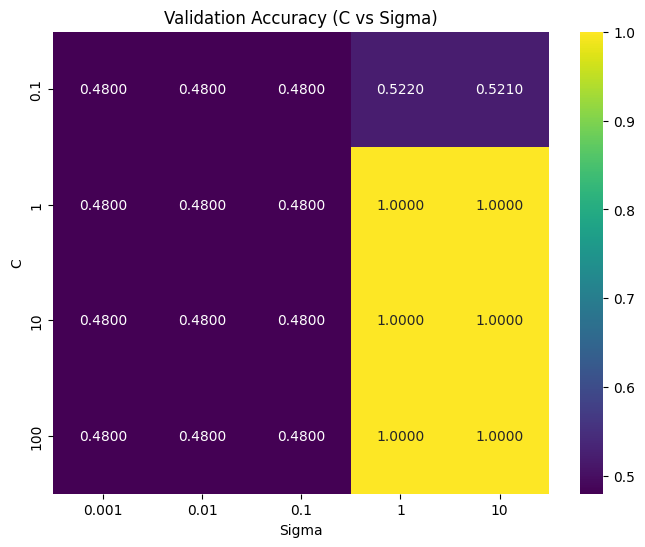

In [91]:
plt.figure(figsize=(8, 6))
seaborn.heatmap(test_accuracies, annot=True, fmt=".4f", cmap="viridis", xticklabels=sigmas, yticklabels=Cs)
plt.xlabel("Sigma")
plt.ylabel("C")
plt.title("Validation Accuracy (C vs Sigma)")
plt.show()

In [93]:
diff_accuracies = train_accuracies - test_accuracies

max_diff_idx = np.unravel_index(np.argmax(diff_accuracies, axis=None), diff_accuracies.shape)
max_diff_C = Cs[max_diff_idx[0]]
max_diff_sigma = sigmas[max_diff_idx[1]]

print(f"The coordinate with the most overfitting is C = {max_diff_C}, sigma = {max_diff_sigma}")
print(f"Training Accuracy at this coordinate:   {train_accuracies[max_diff_idx]:.4f}")
print(f"Validation Accuracy at this coordinate: {test_accuracies[max_diff_idx]:.4f}")
# print(f"Overfitting (Train - Val):              {diff_accuracies[max_diff_idx]:.4f}")

The coordinate with the most overfitting is C = 10, sigma = 0.001
Training Accuracy at this coordinate:   1.0000
Validation Accuracy at this coordinate: 0.4800


In [97]:
x_train, y_train, x_test, y_test = get_datasets_svm(x, y, train_test_split = 0.9, normalize = False)

train_accuracies, test_accuracies = hyperparameter_topography(Cs, sigmas, x_train, y_train, x_test, y_test, tolerance = tolerance)

total dataset size: 10000
train test split: 0.9
x_train: (9000, 50), y_train: (9000, 1)
x_test: (1000, 50), y_test: (1000, 1)
Performing RBF Kernel SVM for C: 0.1, sigma:0.001
    Number of SVs: 4520
    b: 0.9008849564238433
    mu max: 0.09999999880424952, mu min: 0.09911490980401079
    No. of points classified -1: 0
    No. of points classified 1: 1000
    Train accuracy: 0.5022222222222222
    Test accuracy: 0.48
Performing RBF Kernel SVM for C: 0.1, sigma:0.01
    Number of SVs: 4520
    b: 0.9008849569314361
    mu max: 0.09999999880506606, mu min: 0.09911504173085282
    No. of points classified -1: 0
    No. of points classified 1: 1000
    Train accuracy: 0.5022222222222222
    Test accuracy: 0.48
Performing RBF Kernel SVM for C: 0.1, sigma:0.1
    Number of SVs: 4520
    b: 0.9008849569365142
    mu max: 0.09999999880507231, mu min: 0.09911504305010878
    No. of points classified -1: 0
    No. of points classified 1: 1000
    Train accuracy: 0.5022222222222222
    Test accu

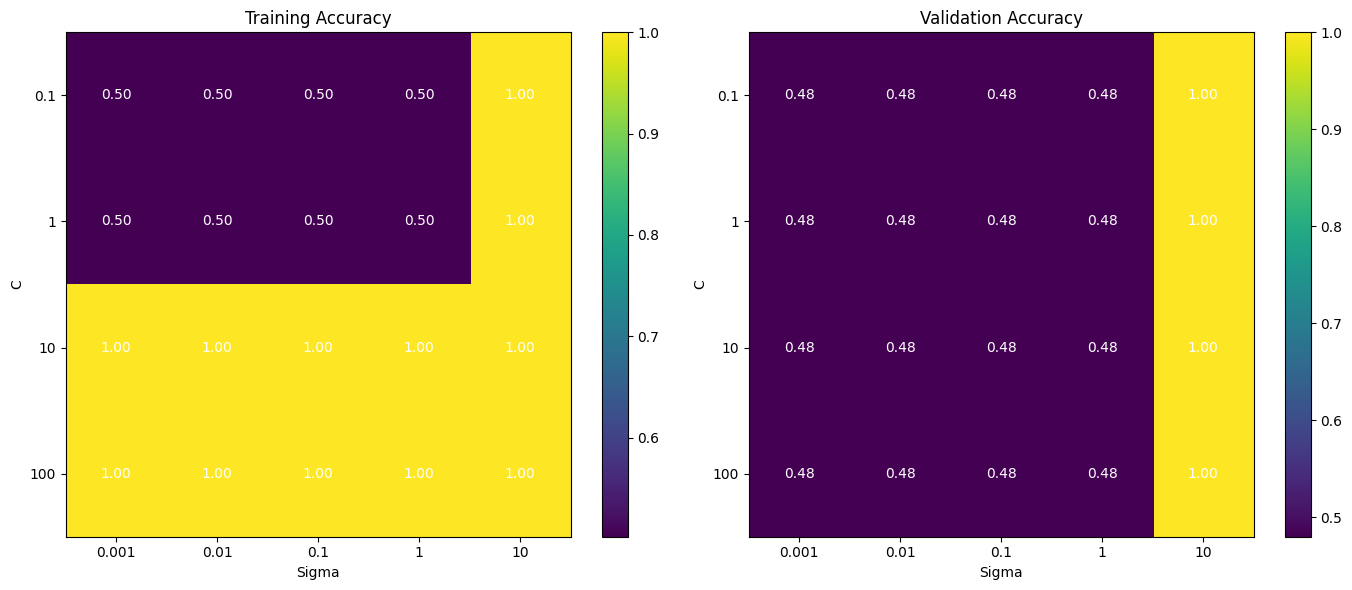

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

mats = [train_accuracies, test_accuracies]
titles = ["Training Accuracy", "Validation Accuracy"]

for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(mat, cmap='viridis', aspect='auto')

    ax.set_xticks(range(len(sigmas)))
    ax.set_yticks(range(len(Cs)))
    ax.set_xticklabels(sigmas)
    ax.set_yticklabels(Cs)

    ax.set_xlabel("Sigma")
    ax.set_ylabel("C")
    ax.set_title(title)

    for i in range(len(Cs)):
        for j in range(len(sigmas)):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center', color='white')

    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()